## Mixture Modeling 
What happens to concentration estimates as you create artificial mixtures of culture

#### Steps 
 1. Calculate Look Time effort Pieccewise inhibition 
 2. Calculate Weighted arrival time
 3. Construct weighted arrival time distribution
 4. Construct mixture models sampled from these distributions

### Piecewise Inhibition

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Optional, List, Tuple


# ----------------------------
# 1) Load all ADC-only CSVs
# ----------------------------
def collect_adc_csvs(data_dir: str, pattern: str = "*.csv", max_files: Optional[int] = None):
    data_path = Path(data_dir)
    files = sorted(data_path.rglob(pattern))
    if max_files:
        files = files[:max_files]
    return files


def load_adc_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)

    required = {"RunTime", "InhibitTimeDiff"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path.name}: missing columns {missing}")

    df["RunTime"] = pd.to_numeric(df["RunTime"], errors="coerce")
    df["InhibitTimeDiff"] = pd.to_numeric(df["InhibitTimeDiff"], errors="coerce")

    df = df.dropna(subset=["RunTime", "InhibitTimeDiff"]).sort_values("RunTime").reset_index(drop=True)
    if len(df) < 2:
        raise ValueError(f"{path.name}: too few rows after cleaning")

    return df


# -----------------------------------------
# 2) Build inhibit intervals for one run
# -----------------------------------------
def inhibit_intervals_from_df(df: pd.DataFrame, abs_tol: float = 1e-6):
    """
    Uses your convention:
      - RunTime is the event/capture time
      - InhibitTimeDiff is the dead time following the previous capture,
        stored on the NEXT row (as in your example file).

    For i = 1..N-1:
      start = RunTime[i-1]
      dt    = RunTime[i] - RunTime[i-1]
      di    = InhibitTimeDiff[i]  (clamped to [0, dt])

    Produces inhibit intervals: [start, start + di]
    Returns normalized times (seconds since run start):
      t0=0, t_end, starts[], ends[]
    """
    t = df["RunTime"].to_numpy(dtype=float)
    dI = df["InhibitTimeDiff"].to_numpy(dtype=float)

    #####################
    #####################
    ### Removed this becuase it was creating artificial high inhibition at time 0 because if t0=t1 inhibition then t0 is always inhibited
    #################
    # normalize time to run start -- 
    # t0 = float(t[0])
    # t = t - t0
    ####################
    ####################

    
    dt = np.diff(t)          # length N-1
    di = dI[1:]              # align with transitions; length N-1

    # clean/clamp
    di = np.where(np.isfinite(di), di, 0.0)
    dt = np.where(np.isfinite(dt), dt, 0.0)
    dt = np.where(dt < 0, 0.0, dt)
    di = np.where(di > abs_tol, di, 0.0)
    di = np.clip(di, 0.0, dt)

    starts = t[:-1]
    ends = starts + di

    m = ends > starts
    starts = starts[m]
    ends = ends[m]

    t_end = float(t[-1])
    return 0.0, t_end, starts, ends


# -----------------------------------------------------
# 3) Aggregate across runs (piecewise-constant p(T))
# -----------------------------------------------------
def piecewise_probability_inhibited(
    csv_paths: List[Path],
    abs_tol: float = 1e-6
) -> pd.DataFrame:
    """
    Returns pw_df with constant counts on intervals [t_start, t_end):
      active = # runs still ongoing at time T
      inhib  = # runs inhibited at time T
      p_inhib = inhib/active
    """
    if not csv_paths:
        return pd.DataFrame(columns=["t_start", "t_end", "active", "inhib", "p_inhib"])

    active_events = []  # (time, delta)
    inhib_events = []   # (time, delta)

    for path in csv_paths:
        try:
            df = load_adc_csv(path)
            t0, t_end, s, e = inhibit_intervals_from_df(df, abs_tol=abs_tol)

            # active coverage for this run
            active_events.append((t0, +1))
            active_events.append((t_end, -1))

            # inhibit intervals
            for a, b in zip(s, e):
                inhib_events.append((float(a), +1))
                inhib_events.append((float(b), -1))

        except Exception as exc:
            print(f"Skipping {path.name}: {exc}")

    if not active_events:
        return pd.DataFrame(columns=["t_start", "t_end", "active", "inhib", "p_inhib"])

    # Build event series and cumulative sums at change points
    ae = pd.DataFrame(active_events, columns=["time", "delta"]).groupby("time", as_index=False)["delta"].sum()
    ie = pd.DataFrame(inhib_events,  columns=["time", "delta"]).groupby("time", as_index=False)["delta"].sum()

    # Union of change points
    times = np.array(sorted(set(ae["time"]).union(set(ie["time"]))), dtype=float)
    if len(times) < 2:
        return pd.DataFrame(columns=["t_start", "t_end", "active", "inhib", "p_inhib"])

    # Map time -> delta using reindex on full time grid
    ae_map = ae.set_index("time").reindex(times, fill_value=0)["delta"].to_numpy()
    ie_map = ie.set_index("time").reindex(times, fill_value=0)["delta"].to_numpy()

    active = np.cumsum(ae_map)
    inhib = np.cumsum(ie_map)

    # piecewise intervals between successive change points
    t_start = times[:-1]
    t_end = times[1:]
    active_i = active[:-1]
    inhib_i = inhib[:-1]

    # probability conditional on being active
    p = np.divide(inhib_i, active_i, out=np.zeros_like(inhib_i, dtype=float), where=active_i > 0)

    pw_df = pd.DataFrame({
        "t_start": t_start,
        "t_end": t_end,
        "active": active_i,
        "inhib": inhib_i,
        "p_inhib": p
    })

    # drop intervals with no active runs (optional, but usually desirable)
    pw_df = pw_df[pw_df["active"] > 0].reset_index(drop=True)
    return pw_df


# -----------------------------------------------------
# 4) Sample to a regular time grid + smooth + plot
# -----------------------------------------------------
def sample_piecewise(pw_df: pd.DataFrame, dt: float = 1.0) -> pd.DataFrame:
    """
    Convert piecewise constant pw_df into regularly sampled grid_df at step dt seconds.
    """
    if pw_df.empty:
        return pd.DataFrame(columns=["time_s", "p_inhib", "active", "inhib"])

    t_max = float(pw_df["t_end"].max())
    t_grid = np.arange(0, t_max + dt, dt)

    # For each grid point, find the interval containing it (right-open)
    starts = pw_df["t_start"].to_numpy()
    idx = np.searchsorted(starts, t_grid, side="right") - 1
    idx = np.clip(idx, 0, len(pw_df) - 1)

    grid_df = pd.DataFrame({
        "time_s": t_grid,
        "p_inhib": pw_df["p_inhib"].to_numpy()[idx],
        "active": pw_df["active"].to_numpy()[idx],
        "inhib": pw_df["inhib"].to_numpy()[idx],
    })
    return grid_df


def plot_p_inhib(
    grid_df: pd.DataFrame,
    smooth_window_s: float = 60.0,   # strong smoothing (seconds)
    dt: float = 1.0,
    show_raw: bool = True,
    title: str = "P(Inhibited at time T | run active)",
    save_path: Optional[str] = None
):
    if grid_df.empty:
        print("grid_df is empty; nothing to plot.")
        return

    y = grid_df["p_inhib"].to_numpy()
    t = grid_df["time_s"].to_numpy()

    # rolling mean smoothing
    if smooth_window_s and smooth_window_s > 0:
        w = max(1, int(round(smooth_window_s / dt)))
        y_smooth = pd.Series(y).rolling(window=w, center=True, min_periods=1).mean().to_numpy()
    else:
        y_smooth = y

    fig, ax = plt.subplots(figsize=(12, 4))
    if show_raw:
        ax.plot(t, y, linewidth=1.0, alpha=0.25, label="raw (sampled)")
    ax.plot(t, y_smooth, linewidth=2.5, label=f"smoothed ({smooth_window_s}s)")

    ax.set_xlabel("Time since run start (s)")
    ax.set_ylabel("Proportion inhibited (0–1)")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.25)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    if save_path:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved figure to: {save_path}")
    plt.show()


# ----------------------------
# 5) One-call convenience
# ----------------------------
def compute_and_plot_probability(
    data_dir: str,
    pattern: str = "*.csv",
    abs_tol: float = 1e-6,
    sample_dt: float = 1.0,
    smooth_window_s: float = 200.0,
    max_files: Optional[int] = None,
    save_path: Optional[str] = None,
    show_raw: bool = True,
    title: str = "P(Inhibited at time T | run active)"
):
    csv_paths = collect_adc_csvs(data_dir, pattern=pattern, max_files=max_files)
    pw_df = piecewise_probability_inhibited(csv_paths, abs_tol=abs_tol)
    grid_df = sample_piecewise(pw_df, dt=sample_dt)

    plot_p_inhib(
        grid_df,
        smooth_window_s=smooth_window_s,
        dt=sample_dt,
        show_raw=show_raw,
        title=title,
        save_path=save_path
    )
    return pw_df, grid_df


In [6]:
## Change this to select which Culture data to analyze

data_dir = "/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/dilExp/Alex/hablab_AlexHighV/merged"


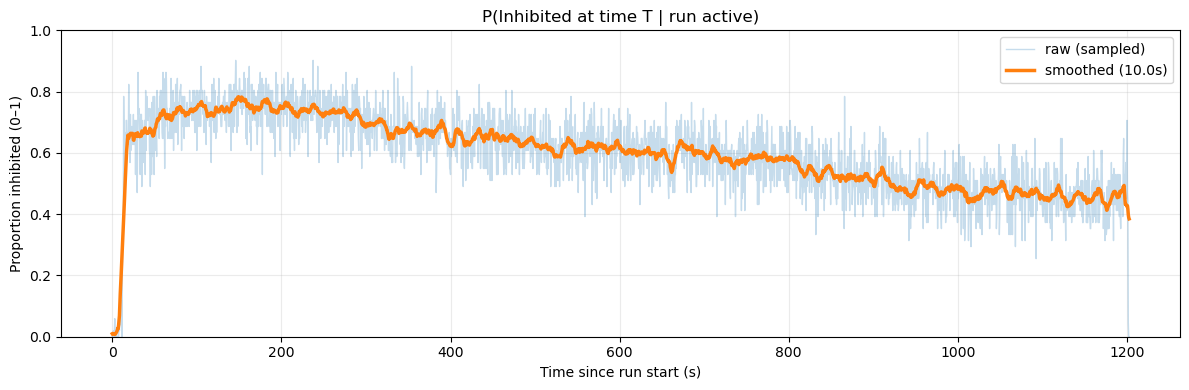

pw_df is actual piecewise section of edges of inhibition across runs
    t_start     t_end  active  inhib   p_inhib
0  0.000000  0.753546      51      0  0.000000
1  0.753546  0.769603      51      1  0.019608
2  0.769603  0.838153      51      2  0.039216
3  0.838153  0.838403      51      1  0.019608
4  0.838403  0.854848      51      2  0.039216
grid_df bins by time intervals and asks of for each run are they at all inhibited within this interval
   time_s   p_inhib  active  inhib
0     0.0  0.000000      51      0
1     0.5  0.000000      51      0
2     1.0  0.000000      51      0
3     1.5  0.019608      51      1
4     2.0  0.000000      51      0


In [7]:

pw_df, grid_df = compute_and_plot_probability(
    data_dir=data_dir,
    pattern="*.csv",   # optional, if you want to target only these
    sample_dt=0.5,              # 1-second sampling for plotting
    smooth_window_s=10.0,      # strong smoothing (e.g., 10 s)
    max_files=None,
   #save_path = "../Figs/dilexp/PropInhibibBeadsTest2.png"
)
print("pw_df is actual piecewise section of edges of inhibition across runs")
print(pw_df.head())
print("grid_df bins by time intervals and asks of for each run are they at all inhibited within this interval")
print(grid_df.head())


In [ ]:
## TO SAVE DATA -- I have already done this for each Culture to be used
# pw_df.to_csv("path/to/save/pw_df.csv", index=False)

### Calculate Weights

logic:  
q(t) = P(IFCB looking at time t)   
λobs​(t) = observed intensity at time t   
λtrue​(t) true intensity at time t  
λobs​(t)=q(t)λtrue​(t)  

therefore:

λtrue​(t) = λobs(t)/q(t)  
using the peicewise inhibition notebook to create a df of q(t) and applying this to df made from the util/class_taxonomicSort

In [8]:
### Compiling RunTimes from directory of CSV files
## may also want to do this later with parquets could make it more intesting but to start keep it simple stupud

from pathlib import Path
import pandas as pd
import numpy as np

def compile_runtimes(directory):
    """
    Compile all values from the 'RunTime' column across all CSV files.

    Parameters
    ----------
    directory : str or Path
        Directory containing CSV files.

    Returns
    -------
    runtimes : np.ndarray
        Array of all runtime values.

    n_files : int
        Number of CSV files that contained a 'RunTime' column.
    """
    runtimes = []
    n_files = 0

    for file in Path(directory).glob("*.csv"):
        df = pd.read_csv(file)

        if "RunTime" in df.columns:
            runtimes.extend(df["RunTime"].dropna())
            n_files += 1

    return np.array(runtimes), n_files

In [9]:
## Get runtimes 
runtime_array, n_runs = compile_runtimes(data_dir)

print(len(runtime_array))
print(runtime_array[:10])
print(f"Number of files processed: {n_runs}")

443832
[ 2.36990451  3.8146441  10.36877821 11.89454861 12.19835503 12.42123698
 12.79516927 13.00693142 13.34828993 13.43846571]
Number of files processed: 51


In [ ]:
## get the piecewise inhibition probabilities from the previously computed dataframe if needed
# pw_df = pd.read_csv("/path/to/your/pw_df.csv")
# print(pw_df.head())


In [10]:
import numpy as np

def compute_ipw_weights(runtimes, inhibit_df, min_capture_prob=0.05):
    """
    Compute inverse probability weights for a list of particle runtimes.

    Parameters
    ----------
    runtimes : array-like
        Particle arrival times.

    inhibit_df : DataFrame
        Must contain columns:
            - t_start
            - t_end
            - p_inhib

    Returns
    -------
    weights : np.ndarray
        Inverse probability weights for each runtime.
    """

    inhibit_df = inhibit_df.sort_values("t_start")

    t_start = inhibit_df["t_start"].to_numpy()
    t_end = inhibit_df["t_end"].to_numpy()
    p_inhibit = inhibit_df["p_inhib"].to_numpy()

    runtimes = np.asarray(runtimes)

    idx = np.searchsorted(t_start, runtimes, side="right") - 1

    p = np.zeros(len(runtimes))

    valid = (
        (idx >= 0) &
        (idx < len(t_start)) &
        (runtimes < t_end[idx])
    )

    p[valid] = p_inhibit[idx[valid]]

    p_capture = np.clip(1 - p, min_capture_prob, 1)

    weights = 1 / p_capture

    return weights

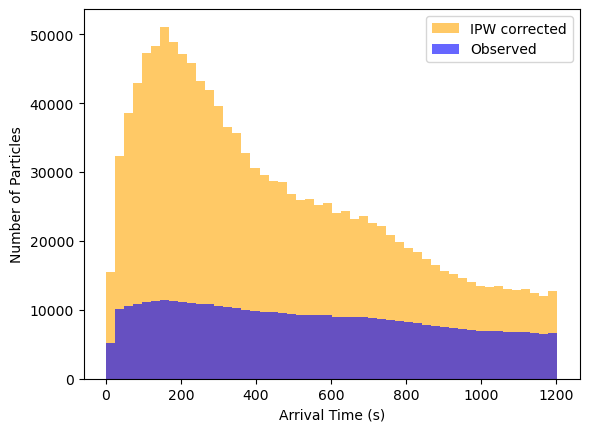

In [12]:
import matplotlib.pyplot as plt
weights = compute_ipw_weights(runtime_array, pw_df, min_capture_prob=0.001)


plt.hist(runtime_array,
         bins=50,
         weights=weights,
         #density=True,
         color='orange',
         alpha=0.6,
         label="IPW corrected")
plt.hist(runtime_array, 
         bins=50, 
         alpha=0.6,
         #density=True,
         color='blue',
         label="Observed")
plt.xlabel("Arrival Time (s)")
plt.ylabel("Number of Particles")

plt.legend()

In [ ]:
## Save Weights
# np.save("path/to/your/weights.npy", weights)

### Build corrected arrival Time distribution

The above weights does not match well with actualy resampling from this distribution so need to empyricaly create a corrected list of artificial arrival times

In [ ]:
## Load runtimes and weights if needed 
## runtime_array, n_runs = compile_runtimes(data_dir)
#weights = np.load("/path/to/your/weights.npy")


In [13]:
import json
import numpy as np
import pandas as pd
from pathlib import Path


def build_corrected_arrival_list(
    df: pd.DataFrame,
    time_col: str = "arrival_time",
    weight_col: str = "weight",
    seed: int | None = None,
    keep_observed_once: bool = True,
    inhibit_time: float = 0.08
) -> dict:
    """
    Build a corrected pseudo-population of arrival times from IPW weights.

    Each observed arrival is expanded into an integer number of pseudo-arrivals.
    The number of copies is sampled from a Poisson distribution with mean equal
    to the IPW weight. This preserves randomness while creating a corrected list
    you can later resample from.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain arrival times and weights.
    time_col : str
        Column name for arrival times.
    weight_col : str
        Column name for IPW weights.
    seed : int or None
        Random seed for reproducibility.
    keep_observed_once : bool
        If True, each observed arrival contributes at least one copy before
        adding Poisson extra copies. If False, total copies are drawn directly
        from Poisson(weight).
    inhibit_time : float
        Maximum time window to jitter the pseudo-arrivals. Each pseudo-arrival
        is sampled uniformly from [arrival_time, arrival_time + inhibit_time].

    Returns
    -------
    dict
        JSON-serializable object with corrected arrival times and metadata.
    """
    rng = np.random.default_rng(seed)

    work = df[[time_col, weight_col]].dropna().copy()
    work[weight_col] = work[weight_col].astype(float)
    work = work[work[weight_col] > 0]

    corrected_times = []
    source_map = []

    for idx, row in work.reset_index(drop=True).iterrows():
        t = float(row[time_col])
        w = float(row[weight_col])

        if keep_observed_once:
            n_copies = 1 + rng.poisson(max(w - 1.0, 0.0)) ## This is the issue I should maybe sample from poisson distrib with sd of inhibit_time/2
        else:
            n_copies = rng.poisson(w)

        for _ in range(n_copies):
            jittered_t = rng.uniform(t, t + inhibit_time) ## this now samples n number of times from uniform distrib from t, t+inhibit_time logic is that is when we are missing particles in that time frame
            corrected_times.append(jittered_t)
            source_map.append(int(idx))

    corrected_times = sorted(corrected_times)

    return {
        "method": "ipw_poisson_expansion",
        "seed": seed,
        "keep_observed_once": keep_observed_once,
        "n_observed": int(len(work)),
        "n_corrected": int(len(corrected_times)),
        "arrival_times": corrected_times,
        "source_index": source_map,
    }


def save_corrected_arrivals(result: dict, output_path: str | Path) -> None:
    output_path = Path(output_path)
    with output_path.open("w") as f:
        json.dump(result, f, indent=2)

In [14]:
working_df = pd.DataFrame({"RunTime": runtime_array, "IPW": weights})

In [16]:
result = build_corrected_arrival_list(
    working_df,
    time_col="RunTime",
    weight_col="IPW",
    seed=42,
    keep_observed_once=True,
    inhibit_time=0.08
)

arrival_times = result["arrival_times"]

print(f"Number of unique arrival times: {len(np.unique(arrival_times))}")
print(f"Number of total arrival times: {len(arrival_times)}")



Number of unique arrival times: 1322715
Number of total arrival times: 1322715


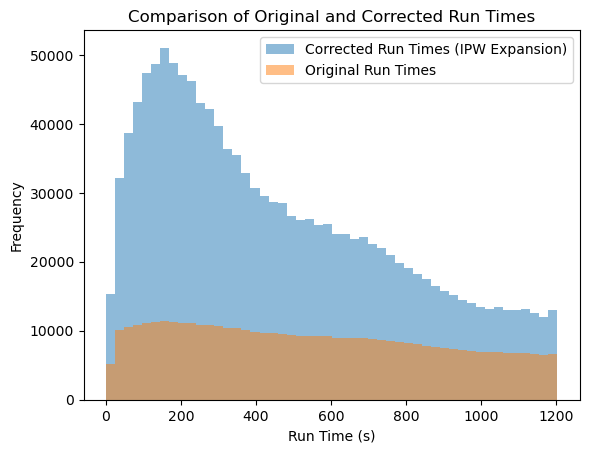

In [18]:
import matplotlib.pyplot as plt

plt.hist(result["arrival_times"], bins=50, alpha=0.5, label="Corrected Run Times (IPW Expansion)")
plt.hist(runtime_array, bins=50, alpha=0.5, label="Original Run Times")
plt.xlabel("Run Time (s)")
plt.ylabel("Frequency")
plt.title("Comparison of Original and Corrected Run Times")
plt.legend()

## Create mixture models
 - sampling from IPW corrected distribution
 - titrate varying mixtures of concentration 
 - Pass through simulated IFCB sampling
 - Calculated bias in concentration estimate incured by IFCB sampling
 

In [ ]:
import pandas as pd
import numpy as np
## Load presaved corrected arrival times
Alex_corrected = pd.read_json("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/dilExp/Alex/AlexHighV_corrected_arrivals.json")
Jata_corrected = pd.read_json("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/dilExp/jataHighV/jataHighV_corrected_arrivals.json")

In [22]:
import numpy as np
import pandas as pd

def make_mixture(
    Arrivals_A,
    Type_A,
    Arrivals_B,
    Type_B,
    total_particles,
    fraction_A,
    scenario_id,
    seed=None,
):
    """
    Arrivals_A: pd.Series of arrival times for type A particles
    Type_A: str, label for type A particles
    Arrivals_B: pd.Series of arrival times for type B particles
    Type_B: str, label for type B particles
    total_particles: int, total number of particles to sample
    fraction_A: float, fraction of type A particles in the mixture
    scenario_id: str, identifier for the scenario
    seed: int, random seed for reproducibility
    """
    rng = np.random.default_rng(seed)

    # Calculate the number of particles of each type
    n_A = int(round(total_particles * fraction_A))
    n_B = total_particles - n_A

    # ## Poisson Sampling (Remove if want exact particle loads)
    # n_A_sampled = rng.poisson(n_A)
    # n_B_sampled = rng.poisson(n_B)
    n_A_sampled = n_A
    n_B_sampled = n_B

    # Sample arrival times for each type
    sampled_A = rng.choice(np.asarray(Arrivals_A), n_A_sampled, replace=False)
    sampled_B = rng.choice(np.asarray(Arrivals_B), n_B_sampled, replace=False)

    # Create DataFrames for each type
    df_A = pd.DataFrame({
        "scenario_id": scenario_id,
        "Source_group": Type_A,
        "arrival_time": sampled_A,
        "total_particles": total_particles,
        "fraction_A": fraction_A
    })

    df_B = pd.DataFrame({
        "scenario_id": scenario_id,
        "Source_group": Type_B,
        "arrival_time": sampled_B,
        "total_particles": total_particles,
        "fraction_A": fraction_A
    })

    # Concatenate the DataFrames and sort by arrival time
    mixture_df = pd.concat([df_A, df_B], ignore_index=True)
    mixture_df = mixture_df.sort_values("arrival_time").reset_index(drop=True)

    return mixture_df

In [23]:
## Wrapper for concentrations

## use this to fill in heat map if you want to see all combinations of a set of target concentrations

def make_mixture_from_concentrations(
    Arrivals_A,
    Type_A,
    Arrivals_B,
    Type_B,
    alex_conc,
    jata_conc,
    scenario_id,
    seed=None,
):
    total_particles = alex_conc + jata_conc
    fraction_A = alex_conc / total_particles

    return make_mixture(
        Arrivals_A=Arrivals_A,
        Type_A=Type_A,
        Arrivals_B=Arrivals_B,
        Type_B=Type_B,
        total_particles=int(total_particles),
        fraction_A=fraction_A,
        scenario_id=scenario_id,
        seed=seed,
    )

In [25]:
## IFCB Simulator from \Modeling\Notebooks\SettlingDistributionModels.ipynb

## trying to change to accept df so dont need to merge

import numpy as np
import pandas as pd

def simulate_ifcb_sampling_df(input_df, arrival_times_col, inhibit_time=0.08):
    """
    Simulate IFCB sampling with a fixed inhibit time after each accepted trigger.

    Parameters
    ----------
    input_df : pandas.DataFrame
        DataFrame containing the particle arrival times.
    arrival_times_col : str
        Name of the column in df that contains the particle arrival times.
        Must be numeric in order of arrival
    inhibit_time : float
        Time after each accepted trigger during which new particles cannot be sampled.

    Returns
    -------
    sampled_df : pandas.DataFrame
        DataFrame containing accepted particle arrival times.
    rejected_df : pandas.DataFrame
        DataFrame containing rejected particle arrival times.
    """
    arrival_times = np.asarray(input_df[arrival_times_col])

    sampled_flags = []
    next_available_time = 0
    total_inhibit = 0
    cumulative_inhibit = []

    for t in arrival_times:
        if t >= next_available_time:
            sampled_flags.append(True)
            next_available_time = t + inhibit_time
            total_inhibit = total_inhibit + inhibit_time
            cumulative_inhibit.append(total_inhibit)
        else:
            sampled_flags.append(False)
            cumulative_inhibit.append(total_inhibit)

    df = input_df.copy()

    df["sampled"] = sampled_flags
    df["cumulative_inhibit"] = cumulative_inhibit


    return df

In [35]:
import numpy as np
import pandas as pd

reps = range(1, 11) ## Number of replicate simulations

## Define target total particle load (concentration * 5mls)
alex_vals = [500, 2500, 5000, 10000, 15000, 20000, 25000]
jata_vals = [500, 2500, 5000, 10000, 15000, 20000, 25000]

results = []

for rep in reps:
    for alex in alex_vals:
        for jata in jata_vals:
            scenario_id = f"Alex{alex}_Jata{jata}"

            mix_df = make_mixture_from_concentrations(
                Arrivals_A=Alex_corrected["arrival_times"],
                Type_A="Alexandrium",
                Arrivals_B=Jata_corrected["arrival_times"],
                Type_B="Jata",
                alex_conc=alex,
                jata_conc=jata,
                scenario_id=scenario_id,
                seed=42 + rep * 1_000_000 + alex * 100 + jata,
            )

            sampled_df = simulate_ifcb_sampling_df(
                mix_df,
                "arrival_time",
                inhibit_time=0.08
            )

            true_alex = (mix_df["Source_group"] == "Alexandrium").sum() / 5
            true_jata = (mix_df["Source_group"] == "Jata").sum() / 5

            sampled_only = sampled_df.loc[sampled_df["sampled"]].copy()

            if sampled_only.empty:
                ifcb_alex = np.nan
                ifcb_jata = np.nan
                vol = np.nan
            else:
                vol = (
                    sampled_only["arrival_time"].max()
                    - sampled_only["cumulative_inhibit"].max()
                ) / 240

                if vol <= 0 or pd.isna(vol):
                    ifcb_alex = np.nan
                    ifcb_jata = np.nan
                else:
                    ifcb_alex = (sampled_only["Source_group"] == "Alexandrium").sum() / vol
                    ifcb_jata = (sampled_only["Source_group"] == "Jata").sum() / vol

            alex_bias = np.nan if true_alex == 0 or pd.isna(ifcb_alex) else (ifcb_alex - true_alex) / true_alex * 100
            jata_bias = np.nan if true_jata == 0 or pd.isna(ifcb_jata) else (ifcb_jata - true_jata) / true_jata * 100

            results.append({
                "rep": rep,
                "scenario_id": scenario_id,
                "alex_concentration": alex,
                "jata_concentration": jata,
                "true_alex_conc": true_alex,
                "true_jata_conc": true_jata,
                "ifcb_alex_conc": ifcb_alex,
                "ifcb_jata_conc": ifcb_jata,
                "Alex_bias": alex_bias,
                "Jata_bias": jata_bias,
            })

results_df = pd.DataFrame(results)

In [36]:
scenarios = results_df["scenario_id"].unique()
jata_biases = []
alex_biases = []
jata_concentrations = []
alex_concentrations = []
for scenario in scenarios:
    average_jata_bias = results_df[results_df["scenario_id"] == scenario]["Jata_bias"].mean()
    average_alex_bias = results_df[results_df["scenario_id"] == scenario]["Alex_bias"].mean()
    average_jata = results_df[results_df["scenario_id"] == scenario]["true_jata_conc"].mean()
    average_alex = results_df[results_df["scenario_id"] == scenario]["true_alex_conc"].mean()
    jata_biases.append(average_jata_bias)
    alex_biases.append(average_alex_bias)
    jata_concentrations.append(average_jata)
    alex_concentrations.append(average_alex)

plotting_df = pd.DataFrame({
    "scenario_id": scenarios,
    "average_Jata_bias": jata_biases,
    "average_Alex_bias": alex_biases,
    "concentration_Alex": alex_concentrations,
    "concentration_Jata": jata_concentrations
})

print(plotting_df.head())

         scenario_id  average_Jata_bias  average_Alex_bias  \
0    Alex500_Jata500          -0.010136          -0.223585   
1   Alex500_Jata2500          -0.821021          -2.335143   
2   Alex500_Jata5000          -0.895108           0.750738   
3  Alex500_Jata10000          -1.891804          -2.944897   
4  Alex500_Jata15000          -2.203218          -0.680311   

   concentration_Alex  concentration_Jata  
0               100.0               100.0  
1               100.0               500.0  
2               100.0              1000.0  
3               100.0              2000.0  
4               100.0              3000.0  


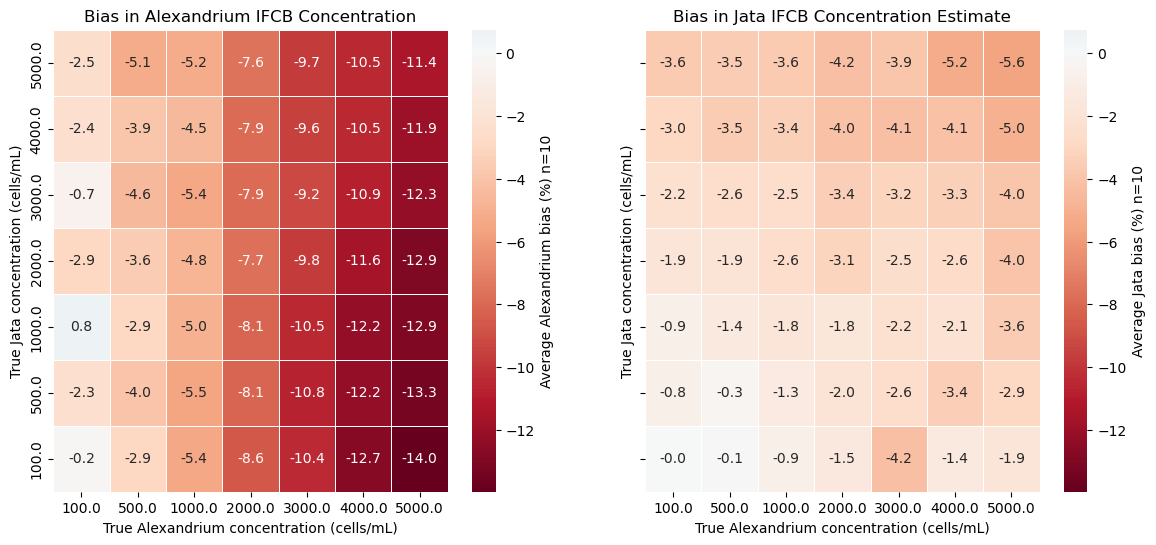

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = plotting_df.copy()

## Create grid values for plotting
alex_vals_grid = [int(x / 5) for x in alex_vals]
jata_vals_grid = [int(x / 5) for x in jata_vals]


# make sure these are numeric
df["concentration_Alex"] = pd.to_numeric(df["concentration_Alex"])
df["concentration_Jata"] = pd.to_numeric(df["concentration_Jata"])

# your intended grid values
alex_levels = np.array(alex_vals_grid, dtype=float)
jata_levels = np.array(jata_vals_grid, dtype=float)

# snap jittered values to nearest intended grid point
def snap_to_grid(x, levels):
    return levels[np.argmin(np.abs(levels - x))]

df["alex_grid"] = df["concentration_Alex"].apply(lambda x: snap_to_grid(x, alex_levels))
df["jata_grid"] = df["concentration_Jata"].apply(lambda x: snap_to_grid(x, jata_levels))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

vmin = min(df["average_Alex_bias"].min(), df["average_Jata_bias"].min())
vmax = max(df["average_Alex_bias"].max(), df["average_Jata_bias"].max())

# Alexandrium bias
alex_grid = df.pivot_table(
    index="jata_grid",
    columns="alex_grid",
    values="average_Alex_bias",
    aggfunc="mean"
).reindex(index=jata_levels[::-1], columns=alex_levels)

sns.heatmap(
    alex_grid,
    ax=axes[0],
    cmap="RdBu",
    center=0,
    vmin=vmin,
    vmax=vmax,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Average Alexandrium bias (%) n=10"}
)
axes[0].set_title("Bias in Alexandrium IFCB Concentration")
axes[0].set_xlabel("True Alexandrium concentration (cells/mL)")
axes[0].set_ylabel("True Jata concentration (cells/mL)")

# Jata bias
jata_grid = df.pivot_table(
    index="jata_grid",
    columns="alex_grid",
    values="average_Jata_bias",
    aggfunc="mean"
).reindex(index=jata_levels[::-1], columns=alex_levels)

sns.heatmap(
    jata_grid,
    ax=axes[1],
    cmap="RdBu",
    center=0,
    vmin=vmin,
    vmax=vmax,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Average Jata bias (%) n=10"}
)
axes[1].set_title("Bias in Jata IFCB Concentration Estimate")
axes[1].set_xlabel("True Alexandrium concentration (cells/mL)")
axes[1].set_ylabel("True Jata concentration (cells/mL)")

#plt.tight_layout()
plt.show()